# Lab 04: Data Cleaning 

Objective: Understand how data cleaning choices alter downstream results and findings. In this lab, you will simulate three different approaches to handling dirty data and analyze how each method tells a different story.

For each question, discuss it with your partner before writing your answer. Be sure to justify your reasoning and reference the data when appropriate.

Your Name(s): Rafael Leme


**Scenario**: The University launched a 3-month "Campus Wellness Pilot," giving smartwatches to 500 students and staff to see if the program increased physical activity over time. You have been handed the dataset (`wellness_tracker.csv`).

This dataset contains daily step counts for each participant over the 3-month period. It has the following columns:
- `user_id`: The unique identifier for each participant.
- `month`: The month of the recorded step count.
- `day`: The day of the recorded step count.
- `steps`: The number of steps recorded by the smartwatch on that day.

---

## Question 1
Do you think the Campus Wellness Pilot will increase physical activity among participants over the 3-month period? Explain your reasoning.

I believe that the Campus Wellness Pilot will indeed increase physical activity among participants in the 3 month period. Because they are being tracked, students may go out of their way to appear as "active/athletic", since it creates a good image to themselves and the people executing the study, and with that, the habit of walking would be increased throughout the study, leading to a increase of physical activity.
___

However, smartwatch data is noisy:
- Some days logged exactly 0 steps (maybe the user took the watch off or left it charging).
- Some days logged NaN (maybe the Bluetooth app failed to sync to the servers).

In [1]:
# let's take a look at the data

# first we need to import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 50)

# load the dataset
df = pd.read_csv('wellness_tracker.csv')
df

,user_id,month,day,steps
0,1,1,1,3651.0
1,1,1,2,0.0
2,1,1,3,4911.0
3,1,1,4,NaN
4,1,1,5,4099.0
...,...,...,...,...
44995,500,3,26,4621.0
44996,500,3,27,0.0
44997,500,3,28,0.0
44998,500,3,29,5342.0


___

## Question 2
What is the unit of observation in this dataset?

The number of steps per month of each student
___

**The Three Cleaning Options**

You must evaluate three different approaches to handling this missing data:
- **Plan A**: Delete any row with a NaN or a 0. 
- **Plan B**: Convert all NaN to 0 steps. 
- **Plan C**: Replace all NaN and 0 values with the overall dataset average. 

___

## Question 3

Before looking at the effects of these plans for cleaning the data, pick which of the three plans you think is the best approach and justify your choice.

I believe that Plan C would be the best approach, since if the student forgot or didn't have their trackers on them, we shouldn't assume that they simply didn't walk that day or invalidate their steps, since it wouldn't be accurate to reality. I believe that approximating their steps by using averages would be the most effective way of dealing with the missing data.
___

In [8]:
# run this cell!

def clean_data(raw_df, strategy):
    """
    Applies a specific cleaning strategy and visualizes the results.
    Accepts strategy 'A', 'B', or 'C'.
    """
    df = raw_df.copy()
    
    if strategy == "A":
        # The Purge: Drop NaNs and zeros
        df = df.dropna(subset=['steps'])
        df = df[df['steps'] > 0]
        title = "Strategy A: Drop Missing & Zeros"
        
    elif strategy == "B":
        # The Pessimist: Assume NaNs are 0s
        df['steps'] = df['steps'].fillna(0)
        title = "Strategy B: Convert Missing to Zeros"
        
    elif strategy == "C":
        # The Imputer: Replace NaNs and 0s with the overall mean
        overall_mean = df[df['steps'] > 0]['steps'].mean()
        df['steps'] = df['steps'].replace(0, np.nan)
        df['steps'] = df['steps'].fillna(overall_mean)
        title = "Strategy C: Impute with Global Mean"
        
    else:
        raise ValueError("Strategy must be 'A', 'B', or 'C'")
    
    return df

def compute_metrics(df):
    # Calculate metrics
    month_1_avg = df[df['month'] == 1]['steps'].mean()
    month_1_records = len(df[df['month'] == 1])

    month_2_avg = df[df['month'] == 2]['steps'].mean()
    month_2_records = len(df[df['month'] == 2])

    month_3_avg = df[df['month'] == 3]['steps'].mean()
    month_3_records = len(df[df['month'] == 3])
    
    # Print summary
    title = f"Cleaning Plan {cleaning_plan}"
    print(f"--- {title} ---")
    print(f"Month 1 Average Steps: {month_1_avg:.0f}")
    print(f"Month 2 Average Steps: {month_2_avg:.0f}")
    print(f"Month 3 Average Steps: {month_3_avg:.0f}")
    print(f"Total valid records remaining in Month 1: {month_1_records}")
    print(f"Total valid records remaining in Month 2: {month_2_records}")
    print(f"Total valid records remaining in Month 3: {month_3_records}")
    print("-" * 30 + "\n")
    
    # Visualize
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='month', y='steps', errorbar=None, hue='month', legend=False)
    plt.title(f"Average Steps by Month\n({title})")
    plt.ylabel("Average Daily Steps")
    plt.xlabel("Month of Program")
    plt.ylim(0, 10000)
    plt.show()


Input your preferred data cleaning strategy below.

In [19]:
cleaning_plan = "B" # Choose between "A", "B", or "C" based on your preferred data cleaning strategy

Now, let's clean the data!

In [20]:
cleaned_df = clean_data(df, cleaning_plan)
cleaned_df.head(10)

,user_id,month,day,steps
0,1,1,1,3651.0
1,1,1,2,0.0
2,1,1,3,4911.0
3,1,1,4,0.0
4,1,1,5,4099.0
5,1,1,6,2751.0
6,1,1,7,2807.0
7,1,1,8,719.0
8,1,1,9,4282.0
9,1,1,10,2904.0


Let's compute statistics for each month and visualize them using a histogram.

--- Cleaning Plan B ---
Month 1 Average Steps: 5238
Month 2 Average Steps: 4623
Month 3 Average Steps: 3994
Total valid records remaining in Month 1: 15000
Total valid records remaining in Month 2: 15000
Total valid records remaining in Month 3: 15000
------------------------------



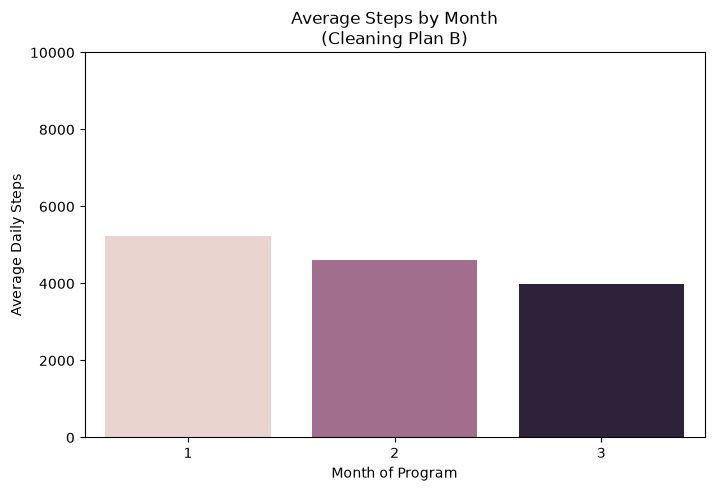

In [21]:
compute_metrics(cleaned_df)

___

## Question 4

Based on the computed metrics and visualizations, do you think the Campus Wellness Pilot increase physical activity over the 3-month period? Explain your reasoning. Is there any information in the computed metrics that might suggest the visualization is misleading?

As shown in the metrics and visualizations, the Campus Wellness Pilot increased physical activity over the 3-month period. The average daily steps increased gradually from Month 1 to Month 3, proving that the tracking lead to a positive trend, which lead to participants to be more physically active. One information in the computed metrics that suggests a misleading visualization is the fact that the Nan and 0 values were completely removed from the data set, which caused metrics to show 15000 valid records for every month, since they were replaced by averages. That might have influenced the results, since the end result was partially based on approximations and not actual evidence.
___

## Question 5

Does this finding align with your expectations from Question 1? Why or why not?

Yes it did, since as predicted, the number of steps increased overtime, since the students started to create a habit on walking, leading to a more active/athletic behavior throughout the 3-month period,
___

## Question 6

Now, go back and try the other two data cleaning plans. You can do this by changing the value of the `cleaning_plan` variable and re-running cells where you create the cleaned dataset and compute the statistics. 

Using the results from the other two cleaning plans, do you think your choice of cleaning plan affected the results? Explain your reasoning. Knowning these results, would you make the same choice again? Why or why not?

My choice of cleaning plan indeed affected the results, since plans A and C shown similar results, with average steps slightly increasing throughout the three months. However, plan B showed the complete opposite, with average steps decreasing from Month 1 to Month 3. This happened because plan B converted every NaN value into 0 steps, even though a NaN could simply mean that the watch failed to record the data, rather than the participant actually not walking during the day. In conclusion, I'd still choose plan C over plan B because replacing missing values with the overall average seems more accurate than assuming that every missing value represented someone that didn't walk at all. However, plan A could also be a good option because it avoids making assumptions about what the missing values represent like in plan C.

## Question 7
Suppose your analysis will be used to inform the college's decision to expand the program. The administration wants a simple "Yes" or "No" on whether to spend $500,000 expanding this program next year. Based on your understanding of the data's flaws, what do you tell them, and which chart do you show to justify it?

No, since the program didn't necessarily fail, but because the data is too sensitive to the cleaning method to justify a $500,000 investment. As shown in Plan B's graph compared to Plans A and C, the data completely changes its direction depending on the approach used to deal with missing data. There is no completely accurate way of measuring data that isn't recorded or tracked without using assumptions, and a program with such big investment isn't justifiable when neglecting / assuming data is stopping the program from seeing if it actually works or not.